## Player Role Assignment

Looking for natural "cutpoints" in the player-season data to identify criteria to split players into player roles for the playing time model. 

In [41]:
import numpy as np
import pandas as pd
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import pymc as pm
from pathlib import Path
from scipy import stats

# Loading data
data_path = Path.cwd()
while not (data_path / "data" / "fangraphs" / "fg_hitters_with_gs.csv").exists() and data_path != data_path.parent:
    data_path = data_path.parent

data_path = data_path / "data" / "fangraphs" / "fg_hitters_with_gs.csv"

print(f"Loading data from {data_path}")
data = pd.read_csv(data_path)

df = data[(data["primary_pos"] != "P") | (data["Name"] == "Shohei Ohtani")][["Name", "Age", "Season", "G", "GS", "GS_pct", "PA", "wRC+", "primary_pos", "same_team", "rookie"]]

Loading data from /Users/johannhatzius/Desktop/GitHub/personal/classes/LSE/ST451-Bayesian_ML/project/data/fangraphs/fg_hitters_with_gs.csv


In [42]:
# Additional features

df["PA/G"] = df["PA"] / df["G"]

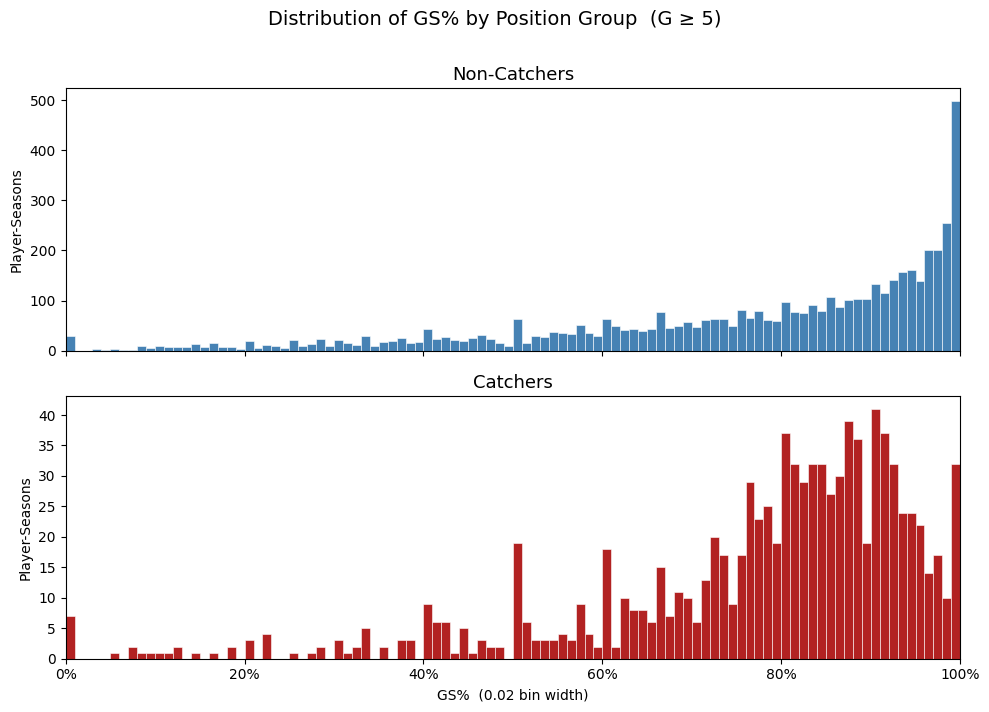

In [43]:
MIN_GAMES = 5  # toggle this

df_filtered   = df[df["G"] >= MIN_GAMES]
catchers      = df_filtered[df_filtered["primary_pos"] == "C"]
non_catchers  = df_filtered[df_filtered["primary_pos"] != "C"]

bins = np.arange(0, 1.01, 0.01)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].hist(non_catchers["GS_pct"].dropna(), bins=bins, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title("Non-Catchers", fontsize=13)
axes[0].set_ylabel("Player-Seasons")

axes[1].hist(catchers["GS_pct"].dropna(), bins=bins, color="firebrick", edgecolor="white", linewidth=0.4)
axes[1].set_title("Catchers", fontsize=13)
axes[1].set_ylabel("Player-Seasons")
axes[1].set_xlabel("GS%  (0.02 bin width)")

for ax in axes:
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

fig.suptitle(f"Distribution of GS% by Position Group  (G ≥ {MIN_GAMES})", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [44]:
starter   = df_filtered["GS_pct"].ge(0.90) | (df_filtered["GS_pct"].ge(0.80) & df_filtered["primary_pos"].eq("C"))
platoon = df_filtered["GS_pct"].between(0.70, 0.90)
part_time = df_filtered["GS_pct"].le(0.70) & df_filtered["PA"].ge(100)
fringe    = df_filtered["GS_pct"].le(0.70) & df_filtered["PA"].lt(100)

counts = {
    "Starter    (GS% ≥ 90%, or ≥ 80% & C)": starter.sum(),
    "Platoon  (70% ≤ GS% ≤ 90%)":         platoon.sum(),
    "Part-time  (GS% ≤ 70%, PA ≥ 100)":     part_time.sum(),
    "Fringe     (GS% ≤ 70%, PA < 100)":     fringe.sum(),
}

for label, n in counts.items():
    print(f"{label} : {n:>5,}")

print(f"\nTotal in df_filtered : {len(df_filtered):>5,}")
print(f"Sum of buckets       : {sum(counts.values()):>5,}")

Starter    (GS% ≥ 90%, or ≥ 80% & C) : 2,569
Platoon  (70% ≤ GS% ≤ 90%) : 2,096
Part-time  (GS% ≤ 70%, PA ≥ 100) :   660
Fringe     (GS% ≤ 70%, PA < 100) : 1,143

Total in df_filtered : 6,130
Sum of buckets       : 6,468


In [49]:
# Classification for intended player roles

conditions = [
    df["GS_pct"].ge(0.95) & df["PA"].ge(50),
    df["GS_pct"].between(0.75, 0.95) & df["PA"].ge(50),
    df["GS_pct"].le(0.75)
]
labels = ["starter", "platoon", "bench"]

df["role"] = np.select(conditions, labels, default=np.nan)

df["role"].value_counts(dropna=False)

role
platoon    2389
bench      2378
starter    1362
nan         298
Name: count, dtype: int64

In [ ]:
### PAs by intended role

## Filters: no rookies, 50PA minimum (full intended seasons only, injuries baked in)

# Method 1: Median
# - Starter: 600PA
# - Platoon: 350PA
# - Bench: 70PA
#
# Method 2: Draw from empirical distribution with the same filters

# Method 3: Outcomes for the "best" starters (>=97% start), different normalization scheme for total at-bats (600PA is the soft projected maximum ABs for the best players),
# soft injury modeling
# - Starter: 600PA
# - Platoon: 300PA
# - Bench: 70PA
#
# Method 2: Draw from empirical distribution with the same filters


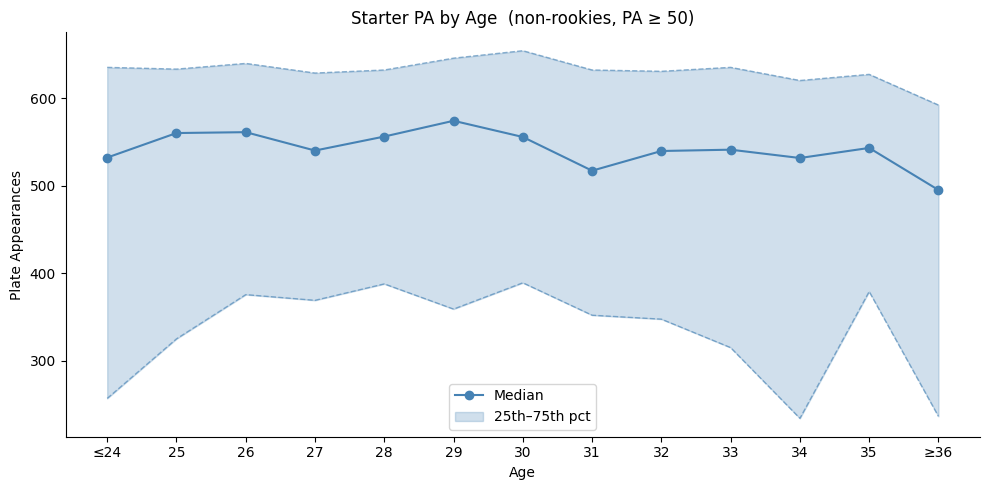

In [47]:
# Method 3

def plot_starter_pa_by_age(df):
    # Filters: non-rookies, 50+ PA, starters only
    starters = df[
        (df["rookie"] != 1) &
        (df["PA"] >= 50) &
        (df["role"] == "starter")
    ].copy()

    # Clip age to [24, 36] — groups <24 and >36 at the boundaries
    starters["age_group"] = starters["Age"].clip(lower=24, upper=36)

    # Percentiles by age group
    grouped = (
        starters.groupby("age_group")["PA"]
        .quantile([0.25, 0.50, 0.75])
        .unstack(level=-1)
        .rename(columns={0.25: "p25", 0.50: "median", 0.75: "p75"})
        .reset_index()
    )

    # X-axis labels: annotate boundary groups
    def age_label(a):
        if a == 24:
            return "≤24"
        if a == 36:
            return "≥36"
        return str(int(a))

    grouped["label"] = grouped["age_group"].apply(age_label)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(grouped["label"], grouped["median"], marker="o", color="steelblue", label="Median")
    ax.fill_between(
        grouped["label"],
        grouped["p25"],
        grouped["p75"],
        alpha=0.25,
        color="steelblue",
        label="25th–75th pct"
    )
    ax.plot(grouped["label"], grouped["p25"], linestyle="--", color="steelblue", alpha=0.6, linewidth=1)
    ax.plot(grouped["label"], grouped["p75"], linestyle="--", color="steelblue", alpha=0.6, linewidth=1)

    ax.set_xlabel("Age")
    ax.set_ylabel("Plate Appearances")
    ax.set_title("Starter PA by Age  (non-rookies, PA ≥ 50)")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    plt.show()

plot_starter_pa_by_age(df)


In [48]:
# Available team PAs by season: ~6100 PA (Fangraphs, Team 2024 leaderboards)